# FNO2d Spectral weights

In [2]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from model_2d import FNO2d, add_grid
from train_utils import UnitGaussianNormalizer, load_data, relative_l2

In [3]:
mode = 0  # 0 = 241 case, 1 = 421 case

difficulty = ["241", "421"]
res = [241, 421]
s_list = [60, 85]

case = difficulty[mode]
r = res[mode]
s = s_list[mode]
n_test = 200

TRAIN_PATH = f"data/piececonst_r{case}_N1024_smooth1.mat"
TEST_PATH = f"data/piececonst_r{case}_N1024_smooth2.mat"
MODEL_PATH = f"outputs/fno2d_{case}_final.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Load data
a_train, u_train = load_data(TRAIN_PATH, 1000, r, s)
a_test, u_test = load_data(TEST_PATH, n_test, r, s)
a_normalizer = UnitGaussianNormalizer(a_train)
u_normalizer = UnitGaussianNormalizer(u_train)

a_test = add_grid(a_normalizer.encode(a_test))

model = FNO2d().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print(f"Fetched {MODEL_PATH}")
model.eval()

def predict_physical(current_model):
    with torch.no_grad():
        pred = current_model(a_test.to(device)).cpu()
    return u_normalizer.decode(pred)

Fetched outputs/fno2d_241_final.pt


### Weight magnitude heatmaps

C:\Users\Galek\AppData\Local\Temp\ipykernel_31320\987762530.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


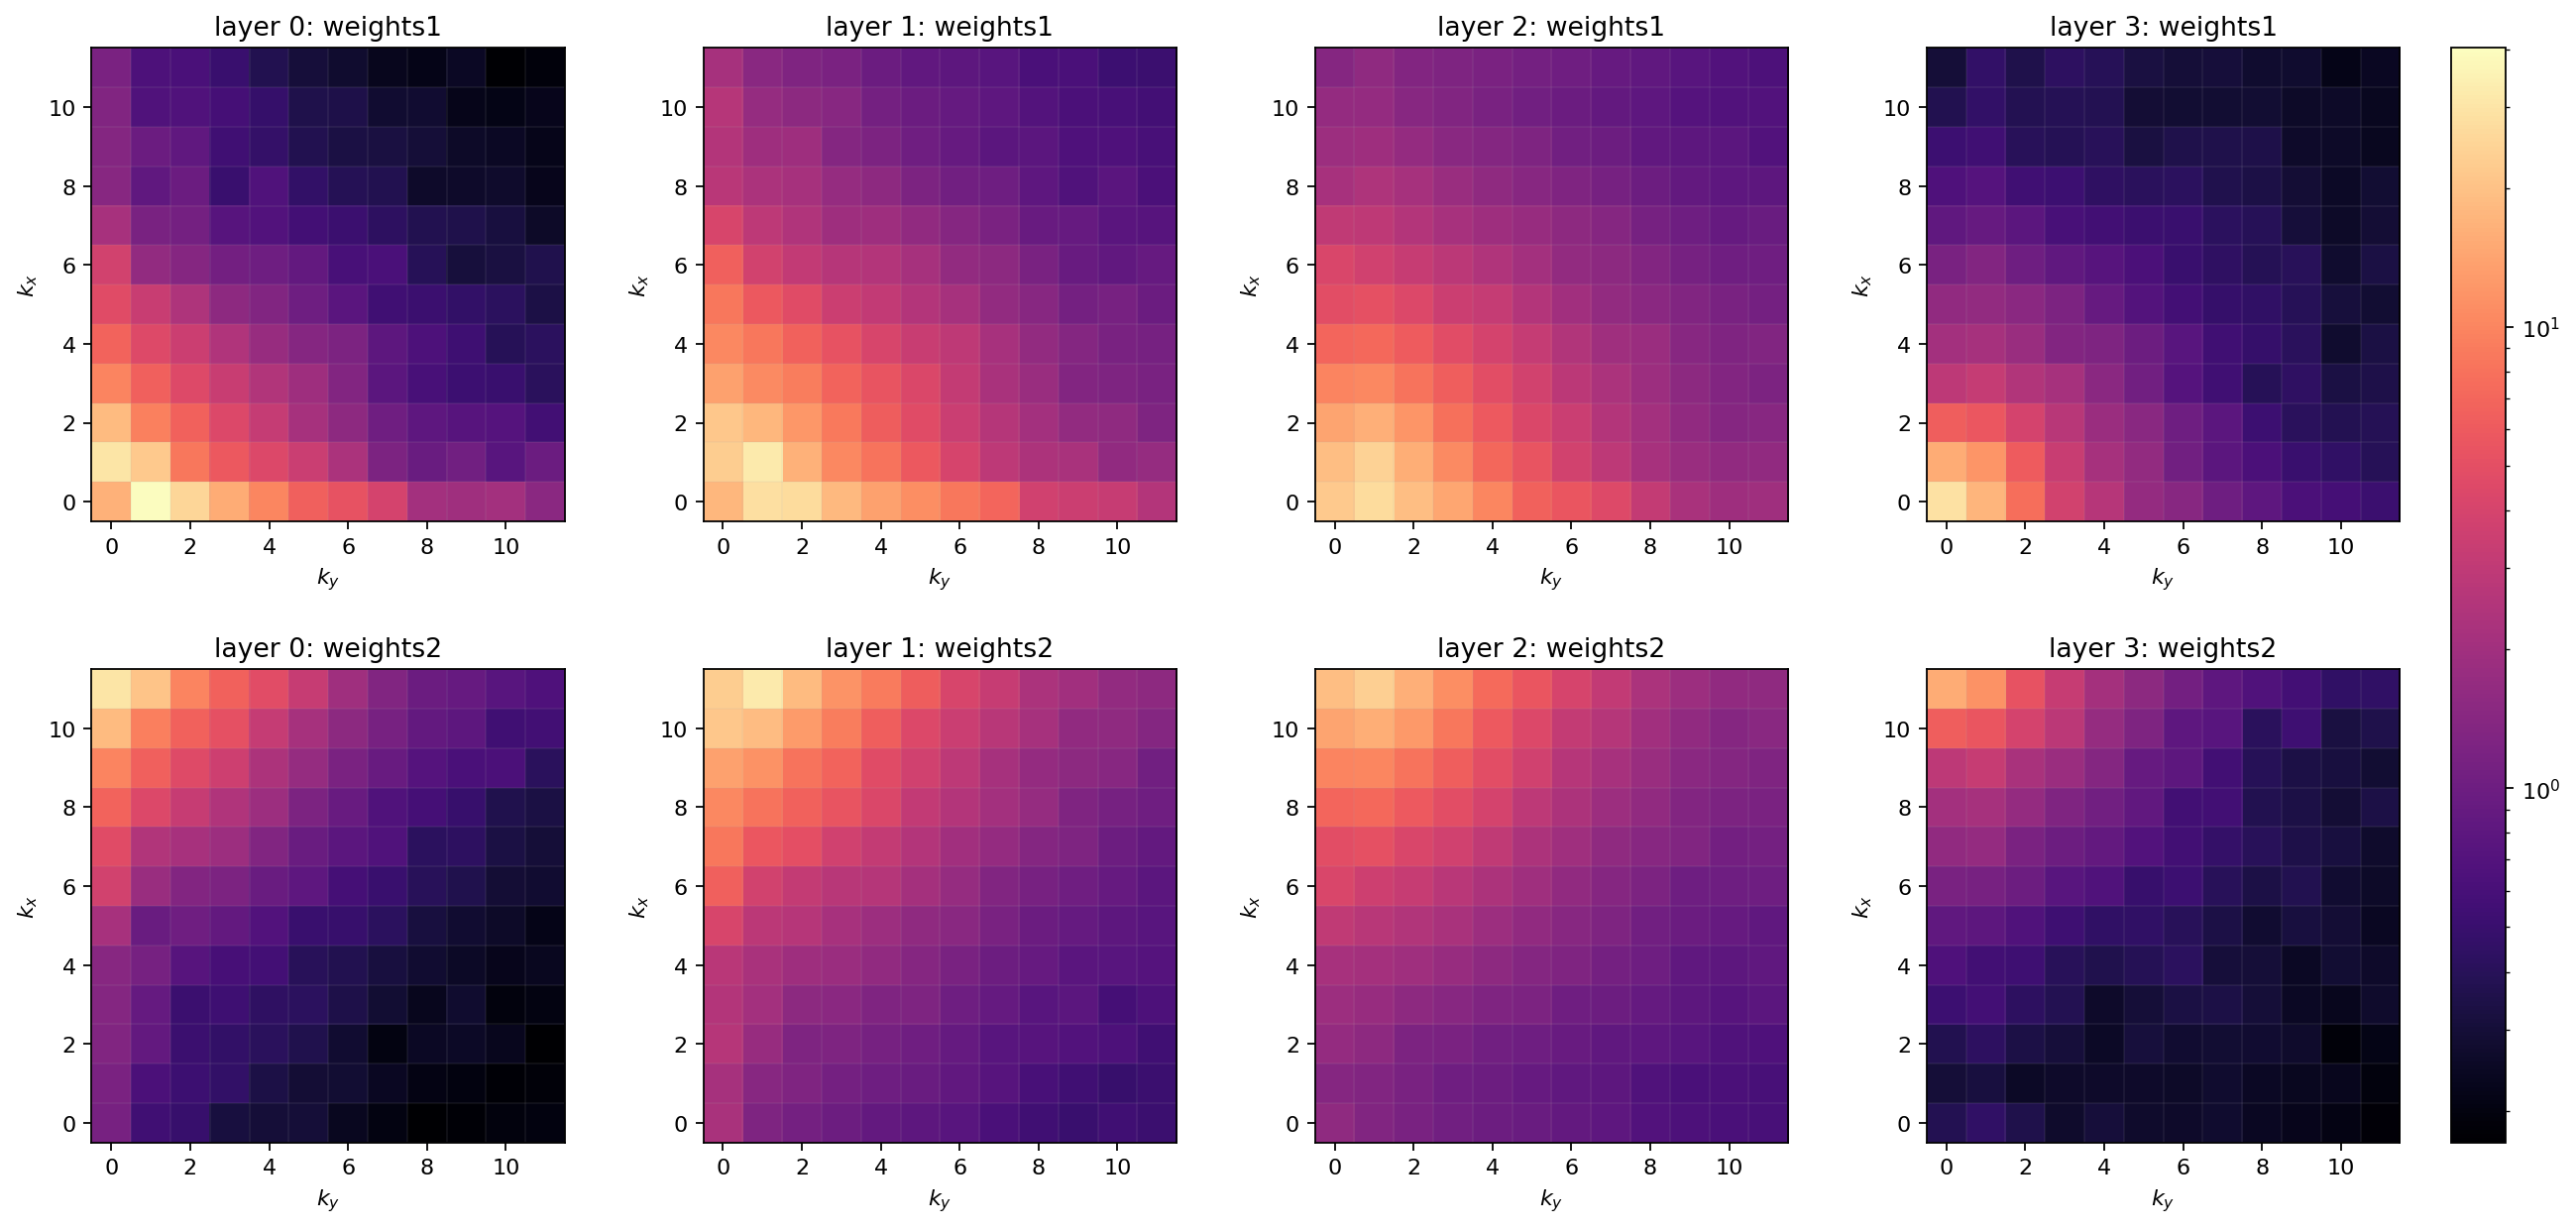

In [96]:
n_layers = len(model.blocks)
n_modes = 12
all_mags = []

for block in model.blocks:
    w1 = block.spectral.weights1.data
    w2 = block.spectral.weights2.data
    all_mags.append(w1.abs().sum(dim=(0, 1)).cpu().numpy())
    all_mags.append(w2.abs().sum(dim=(0, 1)).cpu().numpy())

vmin = min(m.min() for m in all_mags)
vmax = max(m.max() for m in all_mags)

fig, axes = subplots(2, n_layers, figsize=(4*n_layers, 7), dpi=160)

for i, block in enumerate(model.blocks):
    w1 = block.spectral.weights1.data
    w2 = block.spectral.weights2.data
    mag1 = w1.abs().sum(dim=(0, 1)).cpu().numpy()
    mag2 = w2.abs().sum(dim=(0, 1)).cpu().numpy()

    im1 = axes[0, i].imshow(mag1, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, norm='log')
    im2 = axes[1, i].imshow(mag2, origin="lower", cmap="magma", vmin=vmin, vmax=vmax, norm='log')
    axes[0, i].set_title(f"layer {i}: weights1")
    axes[1, i].set_title(f"layer {i}: weights2")

for i, ax in enumerate(axes.flatten()):
    ax.set_xlabel(r"$k_y$")
    ax.set_ylabel(r"$k_x$")
    ax.set_xlim(-0.5, n_modes - 0.5)
    ax.set_ylim(-0.5, n_modes - 0.5)
    ax.set_xticks(np.arange(-0.5, n_modes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_modes, 1), minor=True)
    ax.grid(which='minor', alpha=.1)
    ax.tick_params(which='minor', length=0)

fig.tight_layout(pad=-2, h_pad=2)
fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.02, use_gridspec=True)
fig.show()
